<center><u><H1>Ensemble Methods(BAGGING)</H1></u></center>

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
%matplotlib inline

In [3]:
iris = load_iris()
X=iris.data[50:,[1, 2]]
y=iris.target[50:]
y

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [4]:
le = LabelEncoder()
y = le.fit_transform(y)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [5]:
iris = load_iris()
X=iris.data
y=iris.target

In [6]:
sc = StandardScaler()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=2018)

In [8]:
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

In [9]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

In [10]:
clf_lr = LogisticRegression(l1_ratio=0, C=10, random_state=0)
clf_dt = DecisionTreeClassifier(max_depth=1, criterion='entropy', random_state=2018)
clf_knn = KNeighborsClassifier(n_neighbors=3, p=2, metric='minkowski')

In [11]:
clf_labels = ['Logistic Regression','Decision Tree', 'KNN']

In [12]:
for clf, label in zip([clf_lr, clf_dt, clf_knn], clf_labels):
    scores = cross_val_score(estimator=clf,
                            X=X_train_std,
                            y=y_train,
                            cv=10,
                            scoring='accuracy')
    print('Accuracy: %0.2f (+/- %0.2f) [%s]' % (scores.mean(), scores.std(), label))

Accuracy: 0.96 (+/- 0.05) [Logistic Regression]
Accuracy: 0.68 (+/- 0.03) [Decision Tree]
Accuracy: 0.93 (+/- 0.06) [KNN]


In [13]:
from sklearn.ensemble import VotingClassifier

In [14]:
pipe_lr = Pipeline([['sc', StandardScaler()],['clf_lr', clf_lr]])
pipe_knn = Pipeline([['sc', StandardScaler()],['clf_knn', clf_knn]])

In [15]:
mv = VotingClassifier(estimators=[
    ('lr', pipe_lr), ('dt', clf_dt), ('knn', pipe_knn)], voting='soft')
mv = mv.fit(X_train_std, y_train)
mv_score = cross_val_score(estimator=mv,X=X_train_std,y=y_train,cv=10,scoring='accuracy')

In [16]:
print('ROC AUC: %0.2f (+/- %0.2f) [%s]' % (mv_score.mean(), mv_score.std(), 'Mayority Voting'))

ROC AUC: 0.94 (+/- 0.06) [Mayority Voting]


## Drawing Classifiers

ValueError: X has 2 features, but LogisticRegression is expecting 4 features as input.

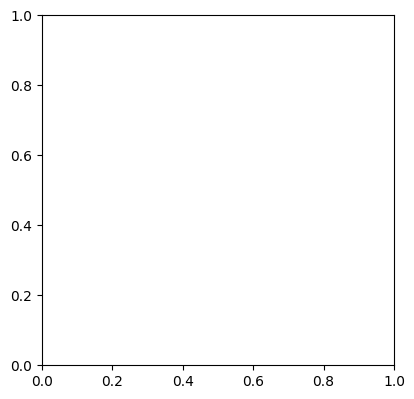

In [17]:
res = 0.02
cl_label = ['Logistic Regression','Decision Tree','KNN','Majority Voting']
models = [clf_lr, clf_dt, clf_knn, mv]
x1min, x1max = X_train_std[:,0].min() -1, X_train_std[:,0].max() + 1
x2min, x2max = X_train_std[:,1].min() -1, X_train_std[:,1].max() + 1
xx, yy = np.meshgrid(np.arange(x1min,x1max,res),np.arange(x2min,x2max,res))

for clf, idx, title in zip(models, np.arange(len(models)), cl_label):        
    fig = plt.figure(1,figsize=(10, 10))
    plt.subplot(2, 2, idx + 1)
    clf.fit(X_train_std, y_train)
    output = clf.predict(np.array([xx.ravel(), yy.ravel()]).T)
    output = output.reshape(xx.shape)
    plt.pcolormesh(xx,yy, output, cmap=plt.cm.coolwarm_r)
    plt.scatter(X_train_std[y_train==0, 0], X_train_std[y_train==0, 1], s=30, color='blue', marker='^')
    plt.scatter(X_train_std[y_train==1, 0], X_train_std[y_train==1, 1], s=30, color='yellow', marker='o')
    plt.xlabel(iris.feature_names[1])
    plt.ylabel(iris.feature_names[2])
    plt.title(title)
              
plt.suptitle("Decision surface of different models")
plt.show()

## Reference:
http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.VotingClassifier.html